In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
data = {
    "Month": ["Jan","Feb","Mar","Apr","May","Jun"],
    "Energy_Usage":[500,520,480,450,430,420],
    "Solar_Energy":[200,210,230,250,270,300],
    "Carbon_Emission":[120,125,110,100,90,80]
}

df = pd.DataFrame(data)

df

,Month,Energy_Usage,Solar_Energy,Carbon_Emission
0,Jan,500,200,120
1,Feb,520,210,125
2,Mar,480,230,110
3,Apr,450,250,100
4,May,430,270,90
5,Jun,420,300,80


In [ ]:
df["Energy_Smoothed"] = df["Energy_Usage"].rolling(window=3).mean()

df

,Month,Energy_Usage,Solar_Energy,Carbon_Emission,Energy_Smoothed
0,Jan,500,200,120,NaN
1,Feb,520,210,125,NaN
2,Mar,480,230,110,500.000000
3,Apr,450,250,100,483.333333
4,May,430,270,90,453.333333
5,Jun,420,300,80,433.333333


In [ ]:
X = np.arange(len(df)).reshape(-1,1)
y = df["Energy_Usage"]

model = LinearRegression()
model.fit(X,y)

next_month = model.predict([[6]])

print("Predicted Energy Usage for Next Month:", next_month)

Predicted Energy Usage for Next Month: [396.66666667]


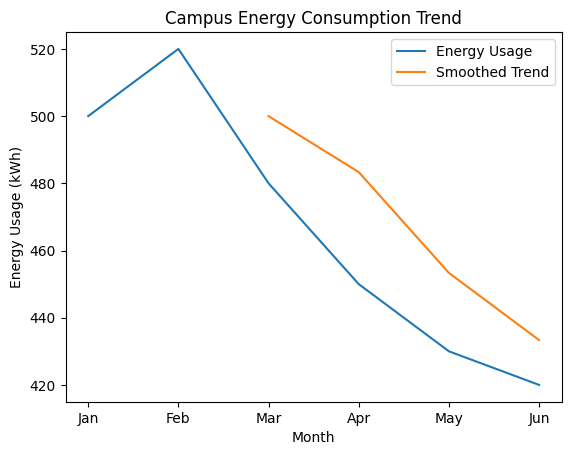

In [ ]:
plt.plot(df["Month"],df["Energy_Usage"],label="Energy Usage")
plt.plot(df["Month"],df["Energy_Smoothed"],label="Smoothed Trend")
plt.xlabel("Month")
plt.ylabel("Energy Usage (kWh)")
plt.title("Campus Energy Consumption Trend")
plt.legend()
plt.show()

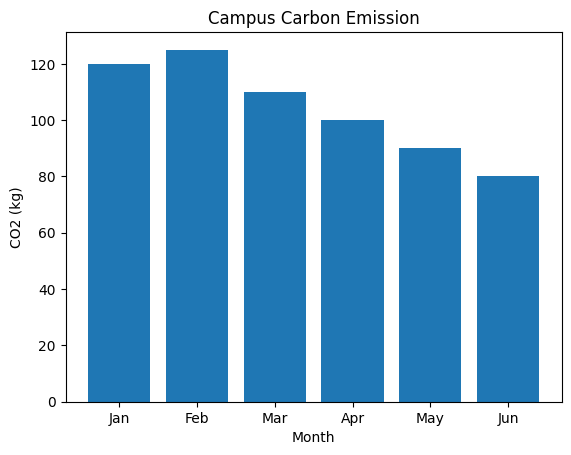

In [ ]:
plt.bar(df["Month"],df["Carbon_Emission"])
plt.title("Campus Carbon Emission")
plt.xlabel("Month")
plt.ylabel("CO2 (kg)")
plt.show()

In [ ]:
carbon_saved = df["Carbon_Emission"].max() - df["Carbon_Emission"].min()

print("Total Carbon Saved:",carbon_saved,"kg")

Total Carbon Saved: 45 kg


In [ ]:
df["Sustainability_Score"] = df["Solar_Energy"] - df["Carbon_Emission"]
df

,Month,Energy_Usage,Solar_Energy,Carbon_Emission,Energy_Smoothed,Sustainability_Score
0,Jan,500,200,120,NaN,80
1,Feb,520,210,125,NaN,85
2,Mar,480,230,110,500.000000,120
3,Apr,450,250,100,483.333333,150
4,May,430,270,90,453.333333,180
5,Jun,420,300,80,433.333333,220


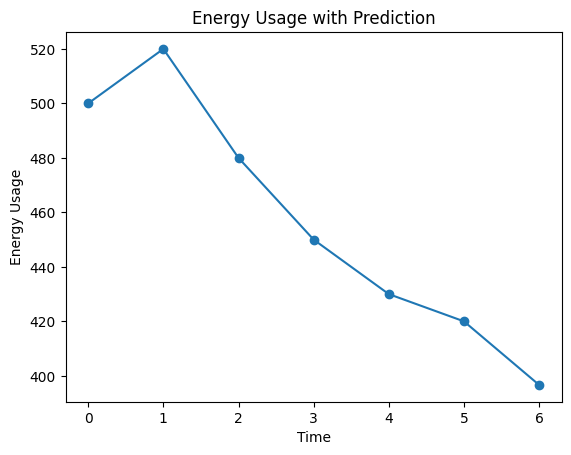

In [ ]:
future = np.append(y, next_month)

plt.plot(range(len(future)), future, marker='o')
plt.title("Energy Usage with Prediction")
plt.xlabel("Time")
plt.ylabel("Energy Usage")
plt.show()